## 1. Import Libraries & Load Data Mentah

**Tujuan:** Memuat dataset mentah langsung dari `data/raw/` (bukan hasil preprocessing di `data/processed/`), sebagai basis untuk membangun model baseline. Model ini nantinya dibandingkan dengan model final (RF & LR) untuk membuktikan secara empiris seberapa besar dampak seluruh proses preprocessing (NB01-08) terhadap performa model.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_raw = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(f"Shape data mentah: {df_raw.shape}")
df_raw.head()

Shape data mentah: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Insight:** Dataset mentah berhasil dimuat dengan shape (5.110 baris, 12 kolom) — jumlah baris lebih banyak dibanding data yang dipakai model final (5.094 baris di NB09/NB10), karena belum melalui proses cleaning (NB03) sama sekali.

## 2. Baseline: Persiapan Data (Tanpa Preprocessing Cermat)

**Tujuan:** Menyiapkan data dengan effort seminimal mungkin — hanya langkah yang secara teknis WAJIB agar model bisa berjalan (tanpa itu, `.fit()` akan error), tanpa satupun keputusan cermat yang sudah dilakukan di NB01-08.

**Definisi "baseline" pada notebook ini:**

| Aspek | Perlakuan di NB01-08 (cermat) | Perlakuan di baseline (asal jalan) |
|---|---|---|
| Missing value | Imputasi median (dipilih karena skewed) | `dropna()` — hapus baris begitu saja |
| Outlier | Domain knowledge klinis | Tidak ditangani |
| Fitur | Diseleksi jadi 6 fitur (uji statistik) | Semua kolom dipakai |
| Encoding | One-hot (dipilih khusus untuk LR, dengan pertimbangan teknis) | Label Encoding semua kolom kategorikal — termasuk yang 3+ kategori (`gender`, `work_type`, `smoking_status`), justru itu bagian dari "asal jalan" yang mau dibuktikan dampaknya |
| Imbalance | `class_weight` + threshold tuning | Tidak ditangani (default sklearn) |

**Catatan metodologi:** karena baseline memakai data mentah yang belum di-*dedup* dan di-*clean* (NB03), test set yang dihasilkan berbeda secara jumlah baris dari model final — namun proporsi imbalance-nya tetap sebanding (~95:5), sehingga perbandingan tetap valid untuk tujuan pembuktian dampak preprocessing secara umum.

In [2]:
df_baseline = df_raw.drop(columns=['id']).copy()

# Missing value: hapus baris NaN, TANPA imputasi cermat
df_baseline = df_baseline.dropna()

# Encoding: Label Encoding SEMUA kolom kategorikal (termasuk 3+ kategori), TANPA mikir one-hot
le = LabelEncoder()
for col in df_baseline.select_dtypes(include='object').columns:
    df_baseline[col] = le.fit_transform(df_baseline[col])

print(f"Shape setelah dropna: {df_baseline.shape}")
print(f"Kolom yang dipakai: {df_baseline.columns.tolist()}")

X_baseline = df_baseline.drop(columns=['stroke'])
y_baseline = df_baseline['stroke']

X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(
    X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline
)
print(f"\nTrain: {X_train_bl.shape} | Test: {X_test_bl.shape}")

Shape setelah dropna: (4909, 11)
Kolom yang dipakai: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Train: (3927, 10) | Test: (982, 10)


C:\Users\k2401\AppData\Local\Temp\ipykernel_21488\183407399.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_baseline.select_dtypes(include='object').columns:


**Insight:** Shape berkurang dari 5.110 menjadi **4.909 baris** setelah `dropna()` — kehilangan **201 baris**, yang persis sama dengan jumlah missing value `bmi` yang ditemukan di NB01. Ini membuktikan konkret perbedaan antara pendekatan baseline (baris langsung dibuang) vs NB03 (nilai kosong diimputasi dengan median, sehingga **tidak ada satu baris pun yang hilang**).

Seluruh 10 fitur mentah dipakai (`gender`, `age`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status`) — termasuk `gender`, `Residence_type`, `ever_married`, `work_type` yang sudah dibuang di NB05 karena gagal uji statistik atau teridentifikasi sebagai proxy dari `age`. Data berhasil dipisah menjadi 3.927 baris training dan 982 baris testing, dengan proporsi kelas yang tetap terjaga lewat `stratify`.

## 3. Baseline RF: Training & Evaluasi

**Tujuan:** Melatih Random Forest dengan setting default polos (tanpa `class_weight`) menggunakan data yang disiapkan seadanya di Section 2, sebagai titik pembanding untuk mengukur dampak seluruh proses preprocessing (NB01-08) dan strategi imbalance-handling (NB09).

=== HASIL RANDOM FOREST BASELINE (Tanpa Preprocessing Cermat) ===
Accuracy : 0.9552
Recall   : 0.0000
Precision: 0.0000
F1-Score : 0.0000


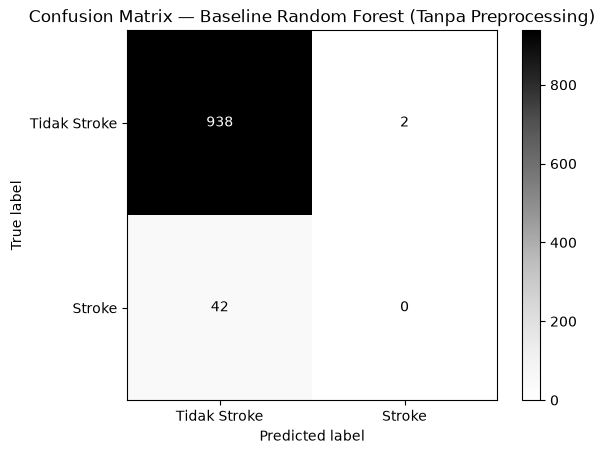

In [3]:
model_baseline_rf = RandomForestClassifier(random_state=42)  # TANPA class_weight, setting default polos
model_baseline_rf.fit(X_train_bl, y_train_bl)

y_pred_bl_rf = model_baseline_rf.predict(X_test_bl)

accuracy_bl_rf = accuracy_score(y_test_bl, y_pred_bl_rf)
recall_bl_rf = recall_score(y_test_bl, y_pred_bl_rf)
precision_bl_rf = precision_score(y_test_bl, y_pred_bl_rf, zero_division=0)
f1_bl_rf = f1_score(y_test_bl, y_pred_bl_rf)

print("=== HASIL RANDOM FOREST BASELINE (Tanpa Preprocessing Cermat) ===")
print(f"Accuracy : {accuracy_bl_rf:.4f}")
print(f"Recall   : {recall_bl_rf:.4f}")
print(f"Precision: {precision_bl_rf:.4f}")
print(f"F1-Score : {f1_bl_rf:.4f}")

cm_bl_rf = confusion_matrix(y_test_bl, y_pred_bl_rf)
disp_bl_rf = ConfusionMatrixDisplay(confusion_matrix=cm_bl_rf, display_labels=['Tidak Stroke', 'Stroke'])
disp_bl_rf.plot(cmap='Greys', values_format='d')
plt.title('Confusion Matrix — Baseline Random Forest (Tanpa Preprocessing)')
plt.savefig('../reports/figures/confusion_matrix_baseline_rf.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Model baseline Random Forest — tanpa imputasi cermat, tanpa domain-knowledge outlier handling, tanpa feature selection, dan tanpa `class_weight` — menghasilkan **Recall 0,0000%**, gagal total mendeteksi seluruh 42 kasus stroke pada test set. Model ini secara harfiah mereplikasi perilaku "model dummy" yang disimulasikan pada NB04 (accuracy 95,52% namun recall 0%), membuktikan bahwa accuracy tinggi (95,52%) sepenuhnya menyesatkan — model tidak mempelajari pola prediktif apapun terhadap kelas minoritas.

## 4. Baseline LR: Training & Evaluasi

**Tujuan:** Melatih Logistic Regression dengan setting default menggunakan data mentah yang sama persis dengan baseline RF (Section 3) — TANPA feature scaling. Section 3 sudah menguji dampak tanpa preprocessing untuk Random Forest; section ini melengkapi dengan menguji hal yang sama untuk Logistic Regression, ditambah satu variabel spesifik: scaling.

Scaling sengaja dilewati karena itu adalah langkah khusus yang baru diterapkan untuk LR di NB10. Dengan melewatinya di sini, section ini bisa menunjukkan dampak scaling secara terisolasi — bukan cuma dampak cleaning atau feature selection saja.

=== HASIL LOGISTIC REGRESSION BASELINE (Tanpa Preprocessing Cermat) ===
Accuracy : 0.9572
Recall   : 0.0000
Precision: 0.0000
F1-Score : 0.0000
Jumlah iterasi sampai konvergen: 301


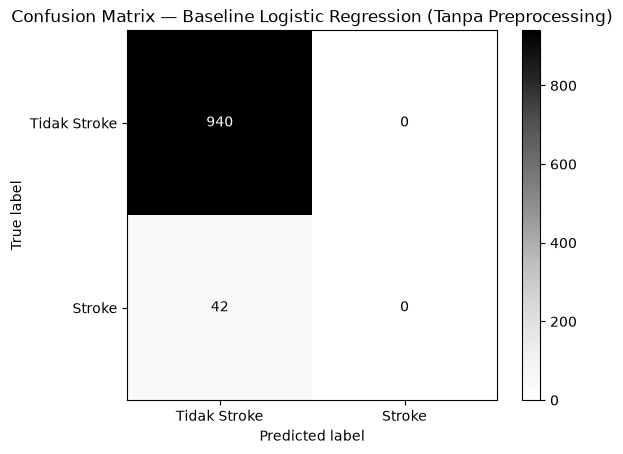

In [4]:
from sklearn.linear_model import LogisticRegression

model_baseline_log = LogisticRegression(random_state=42, max_iter=1000)  # TANPA class_weight, TANPA scaling
model_baseline_log.fit(X_train_bl, y_train_bl)  # pakai data MENTAH, bukan _scaled

y_pred_bl_log = model_baseline_log.predict(X_test_bl)

accuracy_bl_log = accuracy_score(y_test_bl, y_pred_bl_log)
recall_bl_log = recall_score(y_test_bl, y_pred_bl_log)
precision_bl_log = precision_score(y_test_bl, y_pred_bl_log, zero_division=0)
f1_bl_log = f1_score(y_test_bl, y_pred_bl_log)

print("=== HASIL LOGISTIC REGRESSION BASELINE (Tanpa Preprocessing Cermat) ===")
print(f"Accuracy : {accuracy_bl_log:.4f}")
print(f"Recall   : {recall_bl_log:.4f}")
print(f"Precision: {precision_bl_log:.4f}")
print(f"F1-Score : {f1_bl_log:.4f}")
print(f"Jumlah iterasi sampai konvergen: {model_baseline_log.n_iter_[0]}")

cm_bl_log = confusion_matrix(y_test_bl, y_pred_bl_log)
disp_bl_log = ConfusionMatrixDisplay(confusion_matrix=cm_bl_log, display_labels=['Tidak Stroke', 'Stroke'])
disp_bl_log.plot(cmap='Greys', values_format='d')
plt.title('Confusion Matrix — Baseline Logistic Regression (Tanpa Preprocessing)')
plt.savefig('../reports/figures/confusion_matrix_baseline_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Model baseline Logistic Regression — tanpa scaling, tanpa `class_weight`, tanpa preprocessing cermat — menghasilkan Recall **0,0000%** dan bahkan 0 False Positive, artinya model memprediksi "Tidak Stroke" untuk seluruh 982 data test tanpa terkecuali. Ini merupakan replikasi paling murni dari skenario "model dummy" (NB04): accuracy tinggi (95,72%) namun sama sekali tidak mempelajari pola prediktif apapun.

Perbandingan dengan RF baseline (Section 3) menunjukkan LR baseline justru lebih ekstrem — RF baseline masih menghasilkan 2 False Positive, sementara LR baseline benar-benar berhenti total di kelas mayoritas. Ini konsisten dengan diskusi sebelumnya: LR secara struktural lebih sensitif terhadap kondisi data yang belum diproses (skala fitur yang tidak seragam), sehingga tanpa scaling, decision boundary yang terbentuk gagal total memisahkan kelas minoritas.

Sebagai indikator tambahan, model membutuhkan 301 iterasi untuk konvergen — jauh lebih banyak dibanding model final pada NB10 (10 iterasi setelah scaling diterapkan) — menjadi bukti tambahan bahwa scaling tidak hanya memengaruhi akurasi prediksi, tetapi juga efisiensi proses optimisasi model.

## 5. Retrain Model Final (RF & LR)

**Tujuan:** Melatih ulang kedua model final menggunakan data hasil preprocessing lengkap (NB08) dan parameter yang PERSIS SAMA dengan NB09/NB10 — termasuk `random_state=42` yang identik. Karena semua kondisi sama persis dan deterministic, hasilnya seharusnya identik dengan yang sudah didapat sebelumnya, cuma sekarang tersedia di notebook yang sama dengan baseline untuk perbandingan langsung.

In [ ]:
X_train_final = pd.read_csv('../data/processed/X_train.csv')
X_test_final = pd.read_csv('../data/processed/X_test.csv')
y_train_final = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_final = pd.read_csv('../data/processed/y_test.csv').squeeze()

rf_final = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_final.fit(X_train_final, y_train_final)

y_proba_rf_final = rf_final.predict_proba(X_test_final)[:, 1]
y_pred_rf_final = (y_proba_rf_final >= 0.2).astype(int)  # threshold final RF dari NB09

print("=== RANDOM FOREST FINAL (retrain) ===")
print(f"Recall   : {recall_score(y_test_final, y_pred_rf_final):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred_rf_final):.4f}")
print(f"F1-Score : {f1_score(y_test_final, y_pred_rf_final):.4f}")

=== RANDOM FOREST FINAL (retrain) ===
Recall   : 0.6327
Precision: 0.1742
F1-Score : 0.2731


In [6]:
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

# Logistic Regression final (sama persis dengan NB10)
log_final = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_final.fit(X_train_final_scaled, y_train_final)

y_proba_log_final = log_final.predict_proba(X_test_final_scaled)[:, 1]
y_pred_log_final = (y_proba_log_final >= 0.6).astype(int)  # threshold final LR dari NB10

print("=== LOGISTIC REGRESSION FINAL (retrain) ===")
print(f"Recall   : {recall_score(y_test_final, y_pred_log_final):.4f}")
print(f"Precision: {precision_score(y_test_final, y_pred_log_final):.4f}")
print(f"F1-Score : {f1_score(y_test_final, y_pred_log_final):.4f}")

=== LOGISTIC REGRESSION FINAL (retrain) ===
Recall   : 0.8163
Precision: 0.1754
F1-Score : 0.2888


**Insight:** Hasil retraining kedua model mereplikasi secara persis (hingga 4 angka desimal) hasil yang sudah diperoleh pada NB09 (Random Forest: Recall 0,6327) dan NB10 (Logistic Regression: Recall 0,8163). Kecocokan sempurna ini mengonfirmasi bahwa penggunaan `random_state=42` yang identik pada seluruh tahapan (train-test split, inisialisasi model) menghasilkan proses yang sepenuhnya reproducible, sehingga model final aman dijadikan basis perbandingan langsung terhadap baseline pada Section 6.

## 6. Perbandingan Metrik 4 Model

**Tujuan:** Menyatukan hasil keempat model (Baseline RF, Baseline LR, RF Final, LR Final) dalam satu tabel dan satu visualisasi, sebagai bukti utama dampak preprocessing dan strategi imbalance-handling terhadap performa model.

      Model  Accuracy  Recall  Precision  F1-Score
Baseline RF    0.9552  0.0000     0.0000    0.0000
Baseline LR    0.9572  0.0000     0.0000    0.0000
   RF Final    0.8381  0.6327     0.1742    0.2731
   LR Final    0.8067  0.8163     0.1754    0.2888


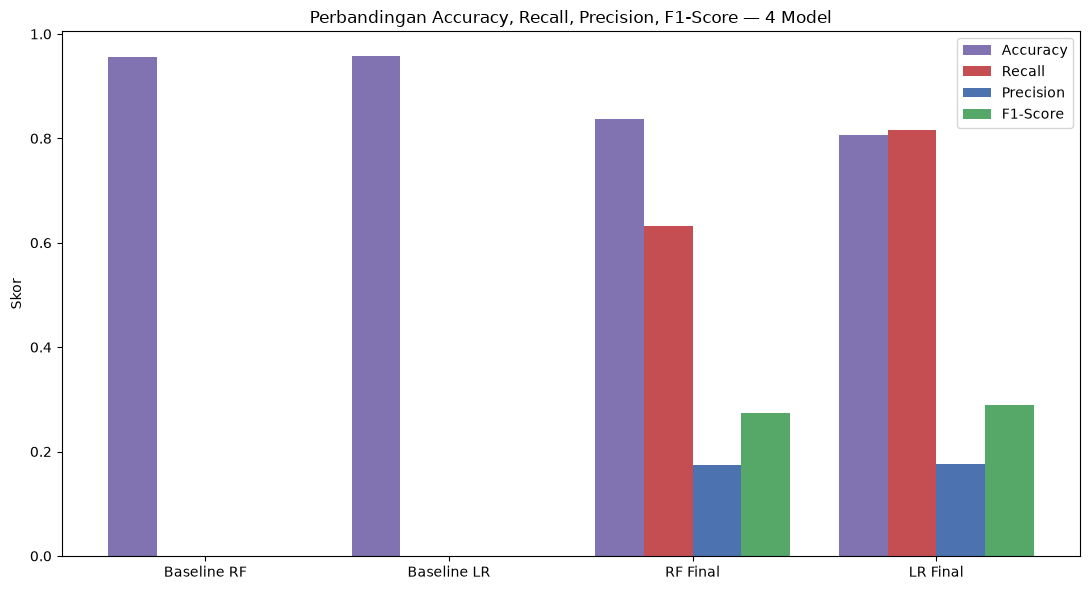

In [8]:
perbandingan_4model = pd.DataFrame({
    'Model': ['Baseline RF', 'Baseline LR', 'RF Final', 'LR Final'],
    'Accuracy': [accuracy_bl_rf, accuracy_bl_log, accuracy_score(y_test_final, y_pred_rf_final), accuracy_score(y_test_final, y_pred_log_final)],
    'Recall': [recall_bl_rf, recall_bl_log, recall_score(y_test_final, y_pred_rf_final), recall_score(y_test_final, y_pred_log_final)],
    'Precision': [precision_bl_rf, precision_bl_log, precision_score(y_test_final, y_pred_rf_final), precision_score(y_test_final, y_pred_log_final)],
    'F1-Score': [f1_bl_rf, f1_bl_log, f1_score(y_test_final, y_pred_rf_final), f1_score(y_test_final, y_pred_log_final)],
})

print(perbandingan_4model.round(4).to_string(index=False))

# Visualisasi bar chart berdampingan — 4 metrik sekaligus
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(perbandingan_4model))
width = 0.2

ax.bar(x - 1.5*width, perbandingan_4model['Accuracy'], width, label='Accuracy', color='#8172B2')
ax.bar(x - 0.5*width, perbandingan_4model['Recall'], width, label='Recall', color='#C44E52')
ax.bar(x + 0.5*width, perbandingan_4model['Precision'], width, label='Precision', color='#4C72B0')
ax.bar(x + 1.5*width, perbandingan_4model['F1-Score'], width, label='F1-Score', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(perbandingan_4model['Model'])
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Accuracy, Recall, Precision, F1-Score — 4 Model')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/perbandingan_4model.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Visualisasi ini menjadi bukti visual langsung dari accuracy paradox yang dibahas sejak NB04. Model baseline (RF: 95,52%, LR: 95,72%) justru menunjukkan **Accuracy tertinggi** dibanding model final (RF Final: ~83,8%, LR Final: ~80,7%) — namun Accuracy tinggi ini sepenuhnya menyesatkan, karena Recall kedua baseline sama-sama 0% (gagal total mendeteksi stroke).

Sebaliknya, model final justru memiliki Accuracy yang lebih RENDAH, tetapi Recall yang jauh lebih baik (RF: 63,3%, LR: 81,6%). Ini adalah trade-off yang **disengaja**: preprocessing dan strategi imbalance-handling secara sadar "mengorbankan" accuracy demi kemampuan mendeteksi kasus stroke yang jauh lebih baik — sesuatu yang tidak akan terlihat jika evaluasi hanya bergantung pada accuracy sebagai metrik tunggal.

## 7. Perbandingan Confusion Matrix

**Tujuan:** Menampilkan keempat confusion matrix berdampingan dalam satu gambar, untuk melihat secara visual pola kesalahan (terutama False Negative) yang berubah drastis antara baseline dan model final.